In [ ]:
from google.colab import files

print("Please upload the 'metals.xlsx' file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please upload the 'metals.xlsx' file:


Saving archive.zip to archive.zip
User uploaded file "archive.zip" with length 16190 bytes


In [ ]:
import zipfile

# Unzip the uploaded archive
zip_file_path = '/content/archive.zip'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Assuming the extracted file is 'Teen_Mental_Health_Dataset.csv'
new_data_file = '/content/Teen_Mental_Health_Dataset.csv'

# Load the new dataset
mental_health_df = pandas_lib.read_csv(new_data_file)

print("First 5 rows of the new dataset:")
print(mental_health_df.head())
print("\nInfo of the new dataset:")
mental_health_df.info()

First 5 rows of the new dataset:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      lo

### Statistical Analysis on 'Teen_Mental_Health_Dataset.csv'

Now, let's perform similar statistical analysis on the `Teen_Mental_Health_Dataset.csv` by selecting relevant numerical columns. I will use 'Coping_Mechanisms', 'Stress_Level', and 'Anxiety_Level' for these calculations.

In [ ]:
# Using 'daily_social_media_hours' as a primary numerical column for demonstration
selected_column = 'daily_social_media_hours'

# Mean
average_selected = mental_health_df[selected_column].mean()
print(f"Mean of {selected_column}:", average_selected)

# Median
median_selected = mental_health_df[selected_column].median()
print(f"Median of {selected_column}:", median_selected)

# Trimmed Mean (using 10% trim)
trimmed_selected_avg = scipy_trim_mean(mental_health_df[selected_column], proportiontocut=0.10)
print(f"Trimmed Mean of {selected_column}:", trimmed_selected_avg)

# 75th Percentile
third_quartile_selected = numpy_lib.percentile(mental_health_df[selected_column], 75)
print(f"75th Percentile of {selected_column}:", third_quartile_selected)

# Variance
variance_selected = stats_lib.variance(mental_health_df[selected_column])
print(f"Variance of {selected_column}:", variance_selected)

# Standard Deviation
std_dev_selected = stats_lib.stdev(mental_health_df[selected_column])
print(f"Standard Deviation of {selected_column}:", std_dev_selected)

# Mean Absolute Deviation
mean_absolute_dev_selected = numpy_lib.mean(numpy_lib.abs(mental_health_df[selected_column] - mental_health_df[selected_column].mean()))
print(f"Mean Absolute Deviation of {selected_column}:", mean_absolute_dev_selected)

# Median Absolute Deviation
median_absolute_dev_selected = numpy_lib.median(numpy_lib.abs(mental_health_df[selected_column] - mental_health_df[selected_column].median()))
print(f"Median Absolute Deviation of {selected_column}:", median_absolute_dev_selected)

# Interquartile Range
interquartile_range_selected = numpy_lib.percentile(mental_health_df[selected_column], 75) - numpy_lib.percentile(mental_health_df[selected_column], 25)
print(f"Interquartile Range of {selected_column}:", interquartile_range_selected)

# Most Frequent Value (Mode)
frequent_value_selected = mental_health_df[selected_column].mode()
print(f"Most Frequent {selected_column} (Mode):", frequent_value_selected[0])

Mean of daily_social_media_hours: 4.536666666666667
Median of daily_social_media_hours: 4.5
Trimmed Mean of daily_social_media_hours: 4.5398958333333335
75th Percentile of daily_social_media_hours: 6.3
Variance of daily_social_media_hours: 4.119271615234918
Standard Deviation of daily_social_media_hours: 2.02959888037881
Mean Absolute Deviation of daily_social_media_hours: 1.7515944444444445
Median Absolute Deviation of daily_social_media_hours: 1.7999999999999998
Interquartile Range of daily_social_media_hours: 3.5
Most Frequent daily_social_media_hours (Mode): 3.5


### Visualizations on 'Teen_Mental_Health_Dataset.csv'

Now, let's create various visualizations for the new dataset. I will pick 'Stress_Level' and 'Anxiety_Level' for some plots to show relationships between different aspects of mental health.

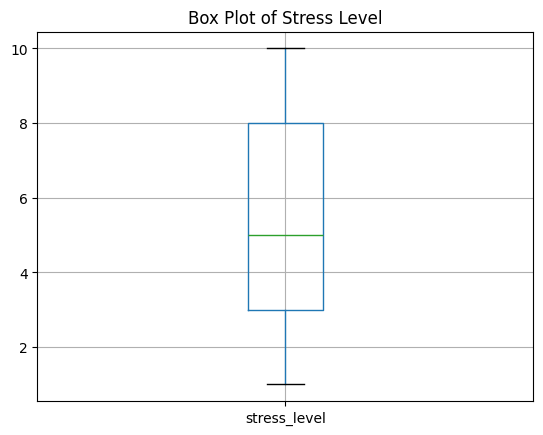

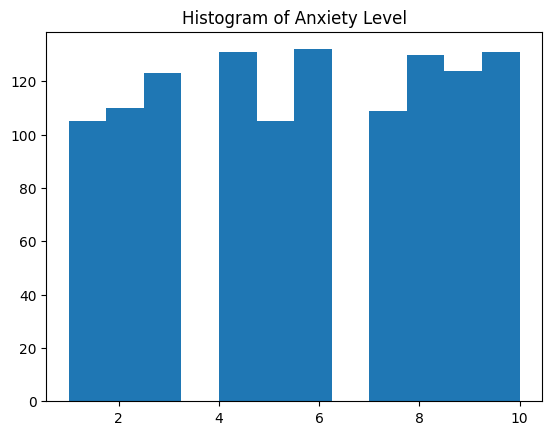

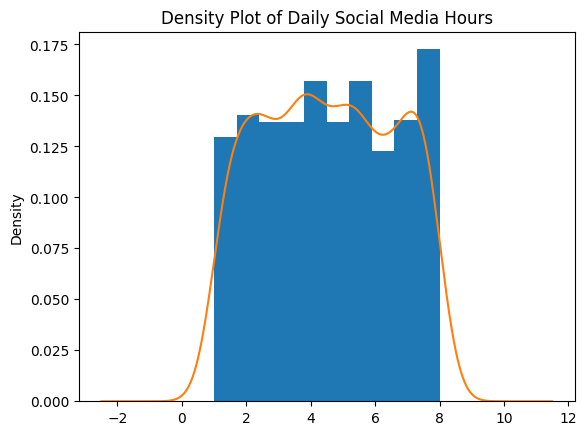

In [ ]:
# Box plot for 'stress_level'
mental_health_df.boxplot(column='stress_level')
plot_sys.title('Box Plot of Stress Level')
plot_sys.show()

# Histogram for 'anxiety_level'
plot_sys.hist(x=mental_health_df['anxiety_level'], bins='auto')
plot_sys.title('Histogram of Anxiety Level')
plot_sys.show()

# Density plot for 'daily_social_media_hours'
density_axis_mh = mental_health_df['daily_social_media_hours'].plot.hist(density=True)
mental_health_df['daily_social_media_hours'].plot.density(ax=density_axis_mh)
plot_sys.title('Density Plot of Daily Social Media Hours')
plot_sys.show()

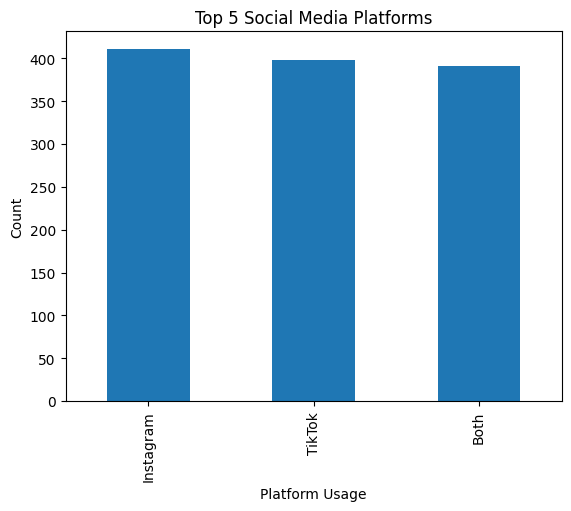

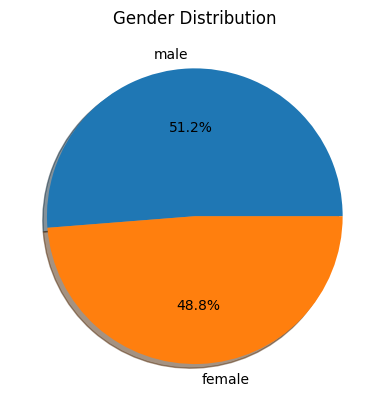

In [ ]:
# Bar plot for top 'platform_usage' categories by count
if 'platform_usage' in mental_health_df.columns:
    top_platform_usage = mental_health_df['platform_usage'].value_counts().nlargest(5)
    top_platform_usage.plot.bar()
    plot_sys.xlabel('Platform Usage')
    plot_sys.ylabel('Count')
    plot_sys.title('Top 5 Social Media Platforms')
    plot_sys.show()

# Pie chart for 'gender' distribution (example)
if 'gender' in mental_health_df.columns:
    gender_counts = mental_health_df['gender'].value_counts()
    plot_sys.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', shadow=True)
    plot_sys.title('Gender Distribution')
    plot_sys.show()

Correlation Matrix of numerical columns:
                               age  daily_social_media_hours  sleep_hours  \
age                       1.000000                 -0.006635     0.001530   
daily_social_media_hours -0.006635                  1.000000    -0.009472   
sleep_hours               0.001530                 -0.009472     1.000000   
screen_time_before_sleep  0.075612                  0.035777     0.010235   
academic_performance     -0.013973                  0.013179     0.021866   
physical_activity         0.011086                  0.025546     0.012701   
stress_level             -0.031208                  0.030698    -0.010979   
anxiety_level             0.026363                  0.027835    -0.011879   
addiction_level           0.038265                 -0.024964    -0.054838   
depression_label          0.010973                  0.175201    -0.190630   

                          screen_time_before_sleep  academic_performance  \
age                                

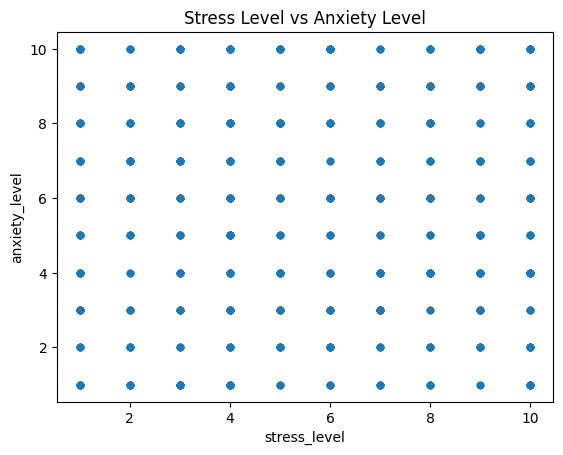

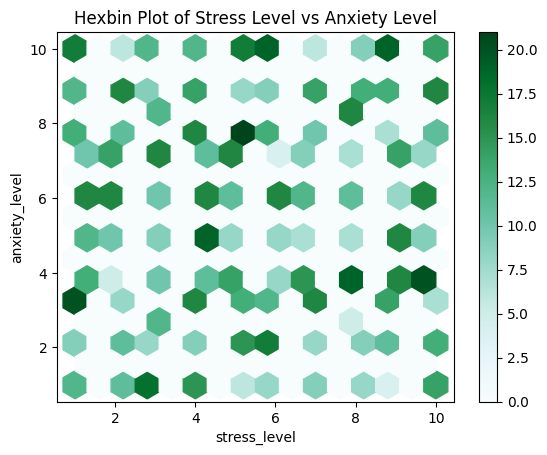

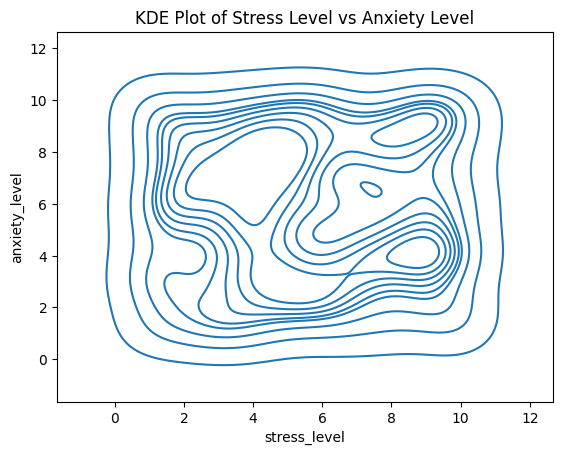

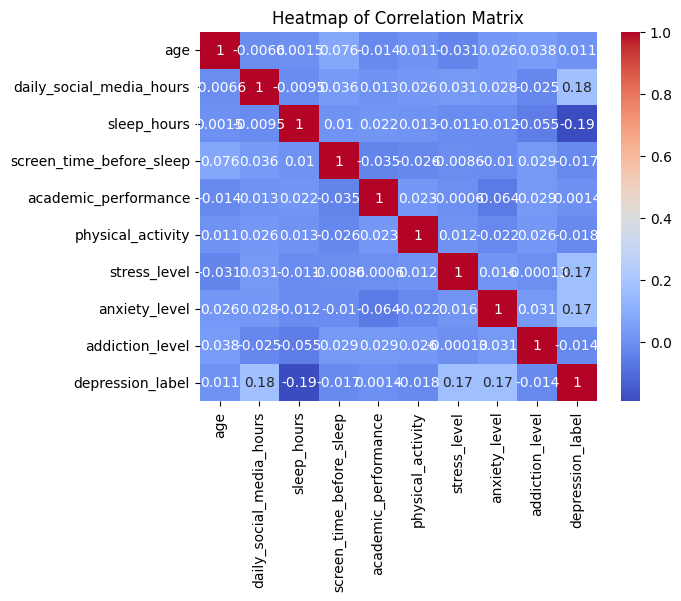

In [ ]:
# Correlation matrix of numerical columns
correlation_matrix_mh = mental_health_df.select_dtypes(include=numpy_lib.number).corr()
print("Correlation Matrix of numerical columns:")
print(correlation_matrix_mh)

# Scatter plot between 'stress_level' and 'anxiety_level'
mental_health_df.plot.scatter(x='stress_level', y='anxiety_level')
plot_sys.title('Stress Level vs Anxiety Level')
plot_sys.show()

# Hexbin plot for 'stress_level' and 'anxiety_level'
mental_health_df.plot.hexbin(x='stress_level', y='anxiety_level', gridsize=15)
plot_sys.title('Hexbin Plot of Stress Level vs Anxiety Level')
plot_sys.show()

# KDE plot for 'stress_level' and 'anxiety_level'
sns_plot.kdeplot(x=mental_health_df['stress_level'], y=mental_health_df['anxiety_level'])
plot_sys.title('KDE Plot of Stress Level vs Anxiety Level')
plot_sys.show()

# Heatmap of the correlation matrix
sns_plot.heatmap(correlation_matrix_mh, annot=True, cmap='coolwarm')
plot_sys.title('Heatmap of Correlation Matrix')
plot_sys.show()

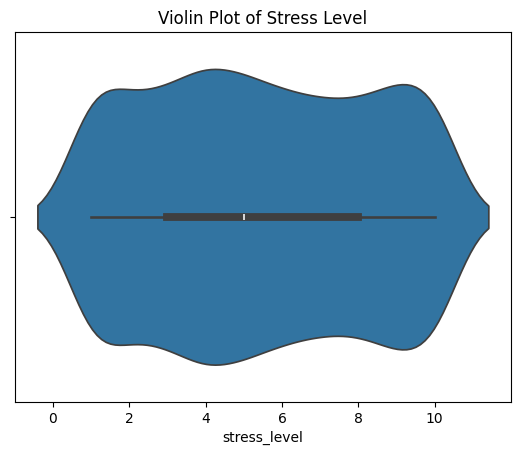

In [ ]:
# Violin plot for 'stress_level'
sns_plot.violinplot(x=mental_health_df['stress_level'])
plot_sys.title('Violin Plot of Stress Level')
plot_sys.show()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


   Rank                    Team/NOC  Gold  Silver  Bronze  Total  \
0     1    United States of America    39      41      33    113   
1     2  People's Republic of China    38      32      18     88   
2     3                       Japan    27      14      17     58   
3     4               Great Britain    22      21      22     65   
4     5                         ROC    20      28      23     71   

   Rank by Total  
0              1  
1              2  
2              5  
3              4  
4              3  
            Rank       Gold     Silver     Bronze       Total  Rank by Total
count  93.000000  93.000000  93.000000  93.000000   93.000000      93.000000
mean   46.333333   3.655914   3.634409   4.322581   11.612903      43.494624
std    26.219116   7.022471   6.626339   6.210372   19.091332      24.171769
min     1.000000   0.000000   0.000000   0.000000    1.000000       1.000000
25%    24.000000   0.000000   0.000000   1.000000    2.000000      23.000000
50%    46.00000

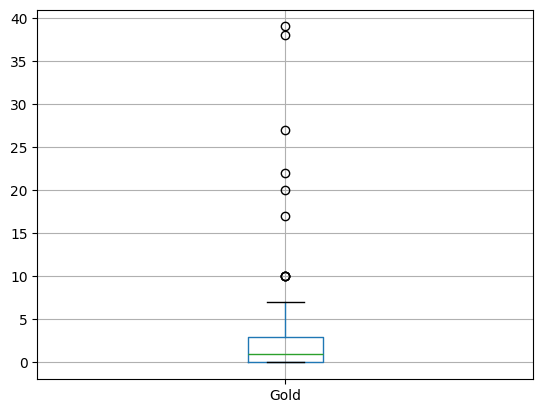

        freq_bin  Rank
0  (-0.039, 3.9]    72
1     (3.9, 7.8]    11
2    (7.8, 11.7]     4
3   (11.7, 15.6]     0
4   (15.6, 19.5]     1
5   (19.5, 23.4]     2
6   (23.4, 27.3]     1
7   (27.3, 31.2]     0
8   (31.2, 35.1]     0
9   (35.1, 39.0]     2


/tmp/ipykernel_3007/3460303829.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frequency_table = frequency_df.groupby('freq_bin')['Rank'].count().reset_index()


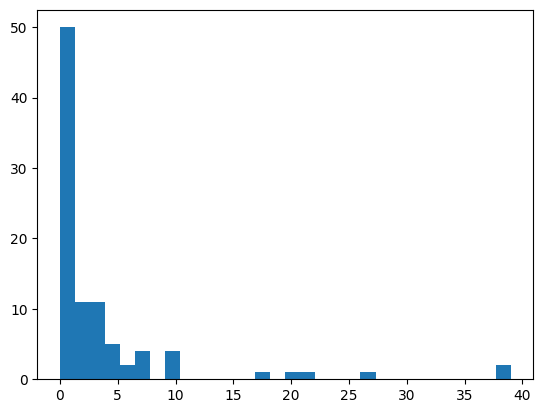

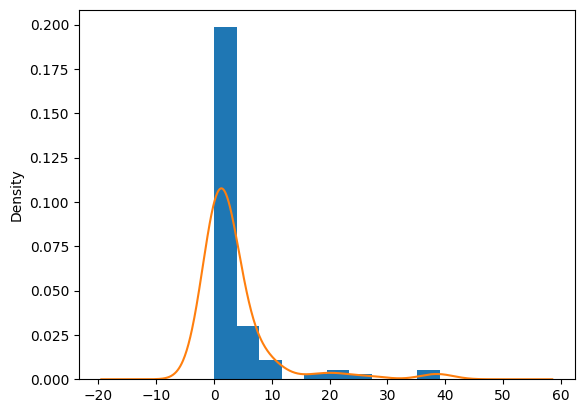

Most Frequent Gold Medal Count (Mode): 0


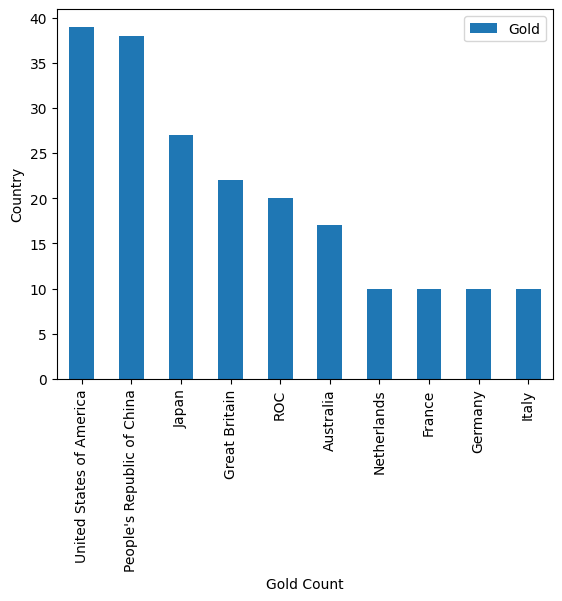

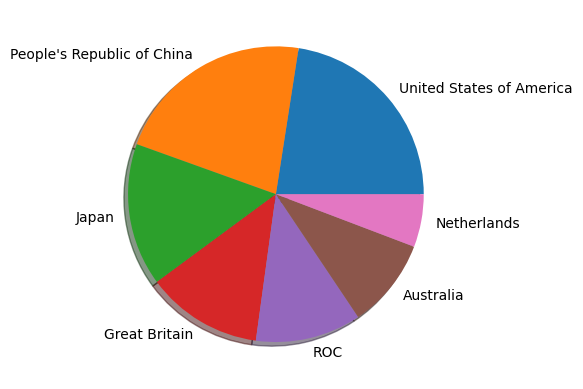

ValueError: could not convert string to float: 'United States of America'

In [ ]:
import pandas as pandas_lib
import numpy as numpy_lib
from scipy.stats import trim_mean as scipy_trim_mean
import statistics as stats_lib
import matplotlib.pyplot as plot_sys
import seaborn as sns_plot

olympic_data = pandas_lib.read_excel('Metals.xlsx')
print(olympic_data.head())
print(olympic_data.describe())

average_total = olympic_data['Total'].mean()
print("Mean of Total Medals:", average_total)

weighted_gold_avg = numpy_lib.average(olympic_data['Gold'], weights=olympic_data['Total'])
print("Weighted Mean of Gold Medals:", weighted_gold_avg)

trimmed_gold_avg = scipy_trim_mean(olympic_data['Gold'], proportiontocut=0.10)
print("Trimmed Mean of Gold Medals:", trimmed_gold_avg)

median_total = olympic_data['Total'].median()
print("Median of Total Medals:", median_total)

sorted_dataset = olympic_data.sort_values('Gold')
cumulative_weights = sorted_dataset['Total'].cumsum()
cutoff_value = sorted_dataset['Total'].sum() / 2
weighted_median_val = sorted_dataset[cumulative_weights >= cutoff_value]['Gold'].iloc[0]
print("Weighted Median of Gold Medals:", weighted_median_val)

third_quartile = numpy_lib.percentile(olympic_data['Total'], 75)
print("75th Percentile of Total Medals:", third_quartile)

gold_variance = stats_lib.variance(olympic_data['Gold'])
print("Variance of Gold Medals:", gold_variance)

gold_std_deviation = stats_lib.stdev(olympic_data['Gold'])
print("Standard Deviation of Gold Medals:", gold_std_deviation)

absolute_deviations = numpy_lib.abs(olympic_data['Gold'] - olympic_data['Gold'].mean())
mean_absolute_dev = numpy_lib.mean(absolute_deviations)
print("Mean Absolute Deviation:", mean_absolute_dev)

median_deviations = numpy_lib.abs(olympic_data['Gold'] - olympic_data['Gold'].median())
median_absolute_dev = numpy_lib.median(median_deviations)
print("Median Absolute Deviation:", median_absolute_dev)

interquartile_range = numpy_lib.percentile(olympic_data['Gold'], 75) - numpy_lib.percentile(olympic_data['Gold'], 25)
print("Interquartile Range of Gold Medals:", interquartile_range)

olympic_data.boxplot(column='Gold')
plot_sys.show()

frequency_df = olympic_data.copy()
frequency_df['freq_bin'] = pandas_lib.cut(olympic_data['Gold'], 10)
frequency_table = frequency_df.groupby('freq_bin')['Rank'].count().reset_index()
print(frequency_table)

plot_sys.hist(x=olympic_data['Gold'], bins='auto')
plot_sys.show()

density_axis = olympic_data['Gold'].plot.hist(density=True)
olympic_data['Gold'].plot.density(ax=density_axis)
plot_sys.show()

frequent_value = olympic_data['Gold'].mode()
print("Most Frequent Gold Medal Count (Mode):", frequent_value[0])

olympic_data.iloc[:10].plot.bar(x='Team/NOC', y='Gold')
plot_sys.xlabel('Gold Count')
plot_sys.ylabel('Country')
plot_sys.show()

pie_subset = olympic_data.iloc[:7]
plot_sys.pie(pie_subset['Gold'], labels=pie_subset['Team/NOC'], shadow=True)
plot_sys.show()

correlation_matrix = olympic_data.corr()
print(correlation_matrix)

olympic_data.plot.scatter(x='Gold', y='silver')
plot_sys.show()

olympic_data.plot.hexbin(x='Gold', y='silver', gridsize=15)
plot_sys.show()

sns_plot.kdeplot(x=olympic_data['Gold'], y=olympic_data['silver'])
plot_sys.show()

sns_plot.heatmap(olympic_data.corr())
plot_sys.show()

contingency_table = olympic_data.pivot_table(index='silver', columns='Gold', aggfunc='size')
contingency_table.fillna(0, inplace=True)
print(contingency_table)

sns_plot.violinplot(x=olympic_data['Gold'])
plot_sys.show()